# Heston Model Results 
---
This notebook presents the results of a generator trained on the **Heston model**.

---
Google Colab case

If you run this notebook on Google Colab, the utils folder is not available by default.
You must therefore download the utils.zip file provided with this notebook and then run the next cell, which extracts the archive and makes the utils folder accessible to Python.

Local case

If you already have the utils folder in the correct location, or if your environment is properly configured,
you can leave the next cell as is, or simply keep it commented.

In [ ]:
import os

BASE = "/content"
os.chdir(BASE)
print("Working directory:", os.getcwd())

# If utils directory does not exist, unzip it
if not os.path.isdir(os.path.join(BASE, "utils")):
    !unzip "utils.zip" -d /content


In [2]:
import torch
import torch.nn as nn

__dtype__ = torch.float32
__device__ = torch.device('cuda:0')

print("GPU available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA (PyTorch) :", torch.version.cuda)
    print("cuDNN :", torch.backends.cudnn.version())

!nvidia-smi

GPU available : True
GPU : Tesla V100-SXM2-32GB
CUDA (PyTorch) : 12.1
cuDNN : 8902
Tue Jan 13 13:57:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           Off |   00000000:18:00.0 Off |                    0 |
| N/A   46C    P0             59W /  300W |   12164MiB /  32768MiB |      0%      Default |
|                                         |              

$$
\textbf{Neural Network Generator}
$$

---

### **Overview**

The **`Generator`** class defines a **neural network-based generative model** designed to produce synthetic samples conditioned on **stochastic noise** and **input parameters**.

This generator maps **random noise** and **model parameters** to **a single output value**, effectively learning to generate a distribution that mimics a target process.

---

### **Architecture**
The generator follows a **feedforward neural network** structure:
1. **Inputs**:  
   - **Noise vector** of size **`noise_size`** (random component).  
   - **Model parameters** of size **`param_size`** (conditioning information).  
2. **Feature Transformations**:  
   - The noise and parameter inputs are **independently projected** to higher dimensions using linear layers:  
     - Noise is mapped to **`noise_dim`**.  
     - Parameters are mapped to **`param_dim_G`**.  
   - The transformed features are concatenated.
3. **Feedforward Layers**:  
   - The concatenated features pass through **`nb_hidden_layers_G`** hidden layers, each with **`hidden_dim_G`** neurons.  
   - Each layer applies:  
     - A **linear transformation**.  
     - A **Softplus activation** function for smooth non-linearity.
4. **Output Layer**:  
   - A final linear layer produces **a single output**.  
   - The final activation function is **Identity**, meaning no transformation is applied to the output.

### **Network representation**

$$
\begin{array}{ccc}
\textbf{Noise Input} & & \textbf{Parameter Input} \\
(\text{size} = \text{noise\_size}) & & (\text{size} = \text{param\_size}) \\
\downarrow & & \downarrow \\
\text{Linear Layer} & & \text{Linear Layer} \\
(\text{noise\_size} \to \text{noise\_dim}) & & (\text{param\_size} \to \text{param\_dim}) \\
\searrow & & \swarrow \\
\end{array}
$$

$$
\begin{array}{c}
\textbf{Concatenation} \\
\downarrow \\
\text{Linear Layer + Softplus} \quad ( \text{noise\_dim + param\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\text{Hidden Layers + Softplus} \quad (\text{hidden\_dim} \to \text{hidden\_dim}) \\
\downarrow \\
\textbf{Final Linear Layer} \quad (\text{hidden\_dim} \to 1) \\
\downarrow \\
\textbf{Output (Single Generated Value)}
\end{array}
$$


In [3]:
class Generator(nn.Module):
    def __init__(self,
                 noise_size: int=1,  # Size of the noise input
                 param_size: int=1,  # Size of the parameter input
                 noise_dim: int=50,  # Dimension after transforming noise input
                 param_dim_G: int=100,  # Dimension after transforming parameter input
                 hidden_dim_G: int=100,  # Number of neurons in hidden layers
                 nb_hidden_layers_G: int=1,  # Number of hidden layers
                 **kwargs):
        super(Generator, self).__init__()
        
        # Store model hyperparameters
        self.noise_size = noise_size
        self.param_size = param_size
        self.noise_dim = noise_dim
        self.param_dim = param_dim_G
        self.nb_hidden_layers = nb_hidden_layers_G
        self.hidden_dim = hidden_dim_G
        
        # Activation function (Softplus for smooth non-linearity)
        self.activation = torch.nn.Softplus(beta=10., threshold=20.0)
        
        # Linear transformations for noise and parameter inputs
        self.input_noise = nn.Linear(self.noise_size, self.noise_dim)
        self.input_param = nn.Linear(self.param_size, self.param_dim)
        
        # List to store hidden layers
        self.fcs = nn.ModuleList()
        for i in range(self.nb_hidden_layers):
            if i == 0:
                # First hidden layer connects transformed noise & parameter inputs
                self.fcs.append(nn.Linear(self.noise_dim + self.param_dim, self.hidden_dim))
            else:
                # Subsequent hidden layers
                self.fcs.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        
        # Output layer (single neuron output)
        self.fcs.append(nn.Linear(self.hidden_dim, 1))
        
        # Final activation (Identity, meaning no transformation at output)
        self.final_activation = torch.nn.Identity()
        
        # Create the sequential model
        self.make_sequential()
    
    def make_sequential(self):
        """
        Constructs a sequential model from the list of layers and activations.
        """
        layers = []
        for i in range(self.nb_hidden_layers):
            layers.append(self.fcs[i])
            layers.append(self.activation)  # Apply activation after each hidden layer
        layers.append(self.fcs[-1])  # Final output layer
        layers.append(self.final_activation)  # No activation at the output
        
        self.M = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass of the generator.
        :param x: Input tensor containing both noise and parameters.
        :return: Generated output.
        """
        
        # Process noise and parameter inputs separately
        noise = self.input_noise(x[:, :self.noise_size])
        params = self.input_param(x[:, self.noise_size:])
        
        # Concatenate processed noise and parameter inputs
        x = torch.cat((noise, params), dim=1)
        
        # Pass through the sequential network
        return self.M(self.activation(x))



$$\textbf{Loading a Generator Model from a Checkpoint}$$

---

### **Overview**

The function **`load_generator_from_dir(dir_model)`** restores a previously trained **Generator** model by:
- Loading the model saved in dir_model.
- Extracting the required layer dimensions from the saved weights.
- Creating a new instance of the Generator with the extracted dimensions.
- Restoring the model's weights.


### **Visual Representation**

\begin{array}{c}
\text{Load Checkpoint} \\
\downarrow \\
\text{Extract Dimensions} \\
\downarrow \\
\text{Instantiate Generator Model} \\
\downarrow \\
\text{Load Weights} \\
\downarrow \\
\textbf{Generator Model Ready}
\end{array}



In [4]:
def load_generator_from_dir(dir_model):
    """
    Loads a Generator model from a saved model, extracting the necessary dimensions and restoring weights.
    :param dir_model: Path to the saved model.
    :return: A Generator model with the loaded weights.
    """
    
    # Load the checkpoint file
    state_dict = torch.load(dir_model, map_location=torch.device('cpu'))
    
    # Extract layer dimensions from the state_dict
    noise_size = state_dict['input_noise.weight'].shape[1]  # Size of the noise input
    param_size = state_dict['input_param.weight'].shape[1]  # Size of the parameter input
    noise_dim = state_dict['input_noise.weight'].shape[0]   # Projected size of noise input
    param_dim_G = state_dict['input_param.weight'].shape[0] # Projected size of parameter input
    hidden_dim_G = state_dict['fcs.0.weight'].shape[0]      # Hidden layer size
    nb_hidden_layers_G = (len([k for k in state_dict.keys() if 'fcs' in k]) - 1) // 2  # Number of hidden layers
    
    # Create a new instance of the model with the extracted dimensions
    model = Generator(
        noise_size=noise_size,
        param_size=param_size,
        noise_dim=noise_dim,
        param_dim_G=param_dim_G,
        hidden_dim_G=hidden_dim_G,
        nb_hidden_layers_G=nb_hidden_layers_G
    )
    
    # Load the saved state_dict into the model
    model.load_state_dict(state_dict)
    
    return model

$$
\textbf{HESTON\_param: A Parameterized Dataset Class for the Heston Model}
$$

---

### **Overview**

The **`HESTON_param`** class generates **parameter samples** for simulating the **Heston stochastic volatility model**.  
It supports:
- **Random sampling**: Parameters are drawn from uniform distributions or constrained distributions.
- **Deterministic mode**: A predefined list of values is used, and all possible **combinations** are generated via the Cartesian product.

---

### **How Parameter Generation Works?**

#### **🔹 Random Sampling Mode**
To generate parameters randomly, each parameter should be provided as a **list of two values**:

$$
[\text{param}_{\min}, \text{param}_{\max}]
$$

- A uniform distribution is used to sample values:

$$
X_{\text{sample}} \sim \mathcal{U}(\text{param}_{\min}, \text{param}_{\max})
$$

- This applies to **KAPPAS, VBARS, RHOS, v0, and T**.
- If a parameter is given as **`[value]`** (size 1), the same parameter is used for all simulations.

##### **Constraint on $\gamma$ (Vol-of-Vol)**
During model training, the **Cox-Ingersoll-Ross (CIR) condition** had to be respected:

$$
\frac{1}{6} < \frac{2 \cdot \kappa \cdot \bar{v}}{\gamma^2} < 10
$$

This **imposes a range for $\gamma$** based on the values of $\kappa$ and $\bar{v}$:

$$
\Gamma_{\text{floor}} = \sqrt{\frac{\kappa \cdot \bar{v}}{5}}, \quad
\Gamma_{\text{cap}} = \min \left( \sqrt{\kappa \cdot \bar{v} \cdot 12}, \Gamma_{\max} \right)
$$

- The sampled **GAMMAS** are drawn from:

$$
\Gamma_{\text{sample}} \sim \mathcal{U}(\Gamma_{\text{floor}}, \Gamma_{\text{cap}})
$$

This ensures that the **Feller condition** for the CIR process is reasonably well-maintained during sampling.

#### **🔹 Non-Random Mode (Cartesian Product)**
To **generate all possible parameter combinations**, each parameter should be given as a list of discrete values:

$$
[\text{param}_1, \text{param}_2, \dots, \text{param}_n]
$$

- The dataset will compute the **Cartesian product** of all parameter lists:

$$
\text{params} = \text{Cartesian\_Product}(\kappa, \gamma, \bar{v}, \rho, v_0, T)
$$

- This ensures that every combination is present in the final dataset.

---

### **Diagram Representation**

$$
\begin{array}{c}
\text{Initialize Dataset} \\
\downarrow \\
\text{Convert Parameters to Tensors} \\
\downarrow \\
\textbf{If Random Sampling:} \\
\quad \text{Sample Uniformly or Apply Constraints} \\
\quad \text{Enforce CIR Condition for $\gamma$} \\
\quad \text{Stack Parameters into a Tensor} \\
\textbf{Else:} \\
\quad \text{Generate Cartesian Product of Parameter Values} \\
\downarrow \\
\text{Dataset Ready!}
\end{array}
$$

---

### **⚠️ Important Warning**
> 🚨 **This class does NOT simulate the Heston model itself!**  
> It only prepares and stores **parameter samples** for simulations.  
> The simulation is defined separately and will use these parameters.




In [5]:
from torch.utils.data import Dataset

class HESTON_param(Dataset):
    def __init__(self,
                 dtype,
                 device: torch.device = torch.device('cuda:0'),
                 log_model: bool = True,
                 random_param: bool = False,
                 KAPPAS: object = [1.],
                 GAMMAS: object = [0.1, 1.0],  # explicit gamma bounds
                 VBARS: object = [1.],
                 RHOS: object = [1.],
                 v0: object = [1.],
                 T: object = [1.],
                 nb_simu: int = 100,
                 feller_ratio: list = [0.15, 10.0],
                 **kwargs):
        self.dtype = dtype
        self.device = device
        self.random_param = random_param
        self.KAPPAS = KAPPAS
        self.GAMMAS = GAMMAS
        self.VBARS = VBARS
        self.RHOS = RHOS
        self.v0 = v0
        self.T = T
        self.nb_simu = nb_simu
        self.feller_ratio = feller_ratio
        self.make_params()

    def __len__(self):
        return self.nb_simu

    def __getitem__(self, index):
        return self.params[index]

    def make_params(self):
        self.KAPPAS_torch = torch.tensor(self.KAPPAS, dtype=self.dtype, device=self.device)
        self.GAMMAS_torch = torch.tensor(self.GAMMAS, dtype=self.dtype, device=self.device)
        self.VBARS_torch = torch.tensor(self.VBARS, dtype=self.dtype, device=self.device)
        self.RHOS_torch = torch.tensor(self.RHOS, dtype=self.dtype, device=self.device)
        self.v0_torch = torch.tensor(self.v0, dtype=self.dtype, device=self.device)
        self.T_torch = torch.tensor(self.T, dtype=self.dtype, device=self.device)

        if self.random_param:
            self.KAPPAS_sample = self._sample_param(self.KAPPAS_torch, self.nb_simu)
            self.VBARS_sample = self._sample_param(self.VBARS_torch, self.nb_simu)

            # Feller bounds
            feller_min, feller_max = self.feller_ratio
            gamma_min_feller = torch.sqrt(2 * self.KAPPAS_sample * self.VBARS_sample / feller_max)
            gamma_max_feller = torch.sqrt(2 * self.KAPPAS_sample * self.VBARS_sample / feller_min)

            # Explicit bounds from GAMMAS input
            gamma_min_input = self.GAMMAS_torch[0]
            gamma_max_input = self.GAMMAS_torch[-1]

            # Final intersection of both constraints
            gamma_floor = torch.clamp(gamma_min_feller, min=gamma_min_input)
            gamma_cap = torch.clamp(gamma_max_feller, max=gamma_max_input)

            self.GAMMAS_sample = gamma_floor + torch.rand(self.nb_simu, device=self.device) * (gamma_cap - gamma_floor)

            self.RHOS_sample = self._sample_param(self.RHOS_torch, self.nb_simu)
            self.v0_sample = self._sample_param(self.v0_torch, self.nb_simu)
            self.T_sample = self._sample_param(self.T_torch, self.nb_simu)

            self.params_stack = torch.stack((self.KAPPAS_sample, self.GAMMAS_sample, self.VBARS_sample,
                                             self.RHOS_sample, self.v0_sample, self.T_sample))
            self.params = self.params_stack.T
        else:
            self.params = torch.cartesian_prod(self.KAPPAS_torch, self.GAMMAS_torch, self.VBARS_torch,
                                               self.RHOS_torch, self.v0_torch, self.T_torch)
            self.nb_simu = len(self.params)

    def _sample_param(self, param_tensor, nb):
        return param_tensor.repeat(nb) if len(param_tensor) == 1 \
               else torch.distributions.Uniform(param_tensor[0], param_tensor[-1]).sample((nb,))


### Simulation of the Heston model

The function `HESTON` simulates terminal log-prices under the Heston stochastic volatility model on a uniform time grid with step size $\Delta t$.

The Heston dynamics are given by

$$
dS_t = -\tfrac{1}{2} V_t\, dt + \sqrt{V_t}\, dW_t^1,
$$

$$
dV_t = \kappa(\bar v - V_t)\, dt + \gamma \sqrt{V_t}\, dW_t^2,
$$

with correlation

$$
d\langle W^1, W^2\rangle_t = \rho\, dt.
$$

#### Numerical scheme

The simulation scheme implemented in the cell below follows classical exact and near-exact methods for the Heston model.

The variance process is simulated using the exact conditional transition of the CIR process, based on a noncentral chi-square representation obtained via a Poisson mixture. 

The log-price process is then updated conditionally on successive variance values using a Gaussian increment and an appropriate drift correction, following the efficient discretisation proposed in *Efficient simulation of the Heston stochastic volatility model*, Andersen (2007), itself inspired by *Exact simulation of stochastic volatility and other affine jump diffusion processes*, Broadie and Kaya (2006).

Given the simulated pair $(V_{t_i}, V_{t_{i+1}})$, the log-price increment is updated as

$$
S_{t_{i+1}} = S_{t_i} + \Delta S_i.
$$

The simulation is performed up to $\max(T)$ and, for each trajectory, the terminal value $S_T$ is extracted at the index corresponding to its own maturity.

#### Output

The function returns a tensor of terminal log-prices $S_T$ of size $N_{\text{traj}}$. Each entry corresponds to one simulated trajectory evaluated at its associated maturity $T$.


In [6]:
def HESTON(kappa, gamma, vbar, rho, v0, T, dt, dtype = torch.float32, device = torch.device('cuda')) :
    """
    Simulate N_traj trajectories of the Heston model using time step dt.
    Simulates paths based on the Heston model for stochastic volatility using discretization of the SDEs.
    
    Parameters:
    - kappa: Mean reversion speed parameter (tensor of size [N_traj]).
    - gamma: Volatility of volatility parameter (tensor of size [N_traj]).
    - vbar: Long-term variance level (tensor of size [N_traj]).
    - rho: Correlation between the two Wiener processes (tensor of size [N_traj]).
    - v0: Initial volatility (tensor of size [N_traj]).
    - T: Time horizon for each trajectory (tensor of size [N_traj]).
    - dt: Time step for discretization (scalar or tensor).
    - dtype: Data type for the simulation (default is torch.float32).
    - device: Device (CPU or GPU) for tensor operations (default is CPU).
    
    Returns:
    - S: A tensor containing the final values of the simulated paths of the Heston process, of shape [N_traj].
      Each i-th element in S corresponds to the final value of the Heston process simulated with the parameters:
      kappa[i], gamma[i], vbar[i], rho[i], v0[i] at the time horizon T[i].
    """
    
    # Calculate the number of time steps (N_steps) required to reach the time horizon T with step size dt.
    N_steps = torch.round(torch.max(T) / dt).to(torch.int32)
    
    # The number of trajectories (N_traj) is determined by the size of the kappa tensor
    N_traj = kappa.shape[0]
    
    # Generate random normal variables (N1) for each step in each trajectory.
    # These random variables will be used to simulate the two Wiener processes in the Heston model.
    N1 = torch.randn(N_steps, N_traj, dtype=dtype, device=device)
    
    # Initialize tensors for the simulated paths of the process (S) and volatility (sigma).
    # S represents the log price (log(X)) with an initial condition of S[0] = 0.
    # sigma represents the volatility process, initialized with v0 at the first time step.
    S = torch.empty(N_steps + 1, N_traj, dtype=dtype, device=device)
    sigma = torch.empty(N_steps + 1, N_traj, dtype=dtype, device=device)
    S[0] = 0  # Initial log price is set to 0 (log(X0) = 0).
    sigma[0] = v0  # Initial volatility is set to v0.
    
    # Calculate the discretized increments for the Wiener process (delta_W1).
    delta_W1 = torch.sqrt(torch.tensor(dt)) * N1
    
    # Define several constants used in the Heston model, calculated based on the given parameters.
    d = 4 * kappa * vbar / gamma**2  # A constant for the chi-square distribution.
    l = 4 * kappa * torch.exp(-kappa * dt) / ((gamma**2) * (1 - torch.exp(-kappa * dt)))  # A scaling factor.
    c = 1.0 / (4.0 * kappa) * (gamma**2) * (1.0 - torch.exp(-kappa * dt))  # Another scaling factor.
    
    # Constants used in the simulation of S.
    k0 = (-rho / gamma * kappa * vbar) * dt
    k1 = (rho * kappa / gamma - 0.5) * dt - rho / gamma
    k2 = rho / gamma
    
    # Loop over all time steps to simulate the volatility and price paths.
    for i in range(0, N_steps):
        # Compute the Poisson process term, based on the current volatility (sigma[i]).
        lda = l * sigma[i]
        Poisson = torch.poisson(lda / 2)  # Generate a Poisson-distributed random variable.
        
        # Update the volatility process at the next time step using a chi-square distribution.
        # The volatility is updated based on the previous volatility and the Poisson term.
        sigma[i + 1] = c * torch.distributions.chi2.Chi2(d + 2 * Poisson).sample()
        
        # Update the log price (S) using the Heston model equation.
        # The price change depends on the current volatility (sigma[i]) and a stochastic increment (delta_W1[i]).
        S[i + 1] = S[i] + k0 + k1 * sigma[i] + k2 * sigma[i + 1] + torch.sqrt((1.0 - rho**2) * sigma[i]) * (delta_W1[i])
    
    # Compute the index corresponding to the final time step T / dt and use it to extract the last values of S.
    index = torch.round(T / dt).to(torch.int32)
    
    # Select the simulated final values of S for each trajectory based on the computed index.
    S = S[index, torch.arange(N_traj)]
    
    # Return the final simulated values of the Heston process for each trajectory.
    return S


### Marginal distribution comparison for the Heston model

The function `show_marginal` compares the marginal distributions generated by the trained model with those obtained from the benchmark Heston simulation.

For each parameter configuration, a large number of independent terminal samples are generated using:
- the benchmark Heston simulator,
- the learned generator model.

Let $S^{\text{true}}$ and $S^{\text{model}}$ denote the corresponding terminal asset prices.  
Both outputs are exponentiated to recover prices and clipped to a fixed cap for numerical stability and visual clarity.

The discrepancy between the two marginal distributions is quantified using the 1-Wasserstein distance

$$
W_1\!\left(S^{\text{true}},\, S^{\text{model}}\right).
$$

#### Procedure

1. Generate $N_{\text{traj}}$ terminal samples from the benchmark Heston model.
2. Generate $N_{\text{traj}}$ terminal samples from the generator using random noise and physical parameters.
3. Exponentiate and clip both samples.
4. Estimate and plot kernel density estimates of the two distributions.
5. Compute and report the Wasserstein distance.

#### Output

For each parameter set, the function displays a density comparison plot and reports the corresponding Wasserstein distance, providing a direct visual and quantitative assessment of the marginal accuracy of the generator under Heston dynamics.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
import numpy as np
import os

def show_marginal(model, dataset, N_traj=50000, dt=0.001, noise_size=5, 
                  cap=3.0, dtype=torch.float32, device=torch.device('cuda'),
                  save_fig_dir=""):
    """
    Display the marginal distributions for the generated samples from the model and compare them
    to the true distribution using the Wasserstein distance.

    Parameters:
    - model: The model used to generate samples (e.g., a GAN or other generative model).
    - dataset: A dataset containing the parameters for the simulations.
    - N_traj: The number of trajectories to simulate (default is 50,000).
    - dt: The time step for discretization (default is 0.001).
    - noise_size: The size of the random noise input to the model (default is 5).
    - cap: Cap used during training to avoid exploding trajectories.
    - dtype: Data type for the tensors (default is torch.float32).
    - device: The device for tensor operations (default is CPU).
    - save_fig_dir: Directory to save plots (if not empty).
    """

    if save_fig_dir:
        os.makedirs(save_fig_dir, exist_ok=True)

    for i, param in enumerate(dataset):
        input_param = param.expand(N_traj, -1).T
        true_sample = HESTON(*input_param, dt=dt, dtype=dtype, device=device)
        relevant_index = torch.where(torch.abs(true_sample) < cap)
        true_sample = true_sample[relevant_index].to('cpu')

        uniform = torch.rand(N_traj, noise_size, device=device)

        if model.input_param.weight.shape[1] == 6:
            INPUT_GAN = torch.cat((uniform, param.unsqueeze(0).repeat((N_traj, 1))), dim=1)
        elif model.input_param.weight.shape[1] == 5:
            INPUT_GAN = torch.cat((uniform, param[:-1].unsqueeze(0).repeat((N_traj, 1))), dim=1)
        else:
            raise ValueError("Model input parameter dimension not recognized.")

        model_sample = model(INPUT_GAN).detach().view(-1).cpu()

        W = wasserstein_distance(true_sample.numpy(), model_sample.numpy())

        print(f"\n📌 Parameter set {i}")
        print(f"    κ = {param[0].item():.3f}   γ = {param[1].item():.3f}   v̄ = {param[2].item():.3f}   ρ = {param[3].item():.3f}   ν0 = {param[4].item():.3f}   T = {param[5].item():.3f}")
        print(f"    📏 Wasserstein distance: {W:.4f}")

        fig, ax = plt.subplots(figsize=(9, 4.5))
        sns.kdeplot(true_sample.numpy(), color='navy', lw=2, label='True Heston', alpha=0.8, ax=ax)
        sns.kdeplot(model_sample.numpy(), color='crimson', lw=2, label='GAN', linestyle='--', alpha=0.8, ax=ax)

        ax.set_title(f"Marginal Distribution Comparison (Parameter set {i+1})", fontsize=20)
        ax.set_xlabel("Sample Value", fontsize=20)
        ax.set_ylabel("Density", fontsize=20)
        ax.legend(fontsize=20)
        ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.6, color="#555555")
        plt.tight_layout()


        # Save figure if requested
        if save_fig_dir:
            κ, γ, v̄, ρ, ν0, T_val = param.tolist()
            filename = f"Heston_set{i}_kappa{κ:.2f}_gamma{γ:.2f}_vbar{v̄:.2f}_rho{ρ:.2f}_nu0{ν0:.2f}_T{T_val:.2f}.eps"
            filename = filename.replace(" ", "").replace(":", "")
            save_path = os.path.join(save_fig_dir, filename)
            plt.savefig(save_path, format="eps", dpi=300)
            print(f"📸 Figure saved to: {save_path}")

        plt.show()


$$
\textbf{Load the models}
$$


In [8]:
# load model with all parameters
dir_model = "utils/models/Heston_model(GAN).pt"  # directory containing the model
model = load_generator_from_dir(dir_model)           # rebuild the model
model.to(__device__)
model.eval()

Generator(
  (activation): Softplus(beta=10.0, threshold=20.0)
  (input_noise): Linear(in_features=5, out_features=150, bias=True)
  (input_param): Linear(in_features=6, out_features=150, bias=True)
  (fcs): ModuleList(
    (0-2): 3 x Linear(in_features=300, out_features=300, bias=True)
    (3): Linear(in_features=300, out_features=1, bias=True)
  )
  (final_activation): Identity()
  (M): Sequential(
    (0): Linear(in_features=300, out_features=300, bias=True)
    (1): Softplus(beta=10.0, threshold=20.0)
    (2): Linear(in_features=300, out_features=300, bias=True)
    (3): Softplus(beta=10.0, threshold=20.0)
    (4): Linear(in_features=300, out_features=300, bias=True)
    (5): Softplus(beta=10.0, threshold=20.0)
    (6): Linear(in_features=300, out_features=1, bias=True)
    (7): Identity()
  )
)

### Typical parameter testing for the Heston model

This experiment evaluates the generator on representative, market-consistent Heston parameter configurations.

The typical parameter sets are chosen within the training domain and correspond to calibrated regimes commonly encountered in equity option markets. The training ranges are defined as

$$
\kappa \in [0.5,\,4.0], \qquad
\bar v \in [0.01,\,0.15], \qquad
\rho \in [-1.0,\,-0.3], \qquad
v_0 \in [0.01,\,0.12],
$$

and

$$
\gamma \in \Big[
\max\!\big(\sqrt{\kappa \bar v / 5},\,0.1\big),\;
\min\!\big(\sqrt{12\,\kappa \bar v},\,0.8\big)
\Big].
$$

This parametrization guarantees that the Feller ratio satisfies

$$
\frac{2\kappa \bar v}{\gamma^2} \;\in\; \Big[\tfrac{1}{6},\,10\Big],
$$

ensuring non-degenerate variance dynamics while allowing for both weak and strong mean reversion regimes.

The maturities are selected in the range

$$
T \in \left[\tfrac{60}{365},\,\tfrac{365}{365}\right].
$$

The selected configurations are strictly in-domain and are used to assess the accuracy of the learned generator under typical calibrated market conditions, rather than stress or extrapolation scenarios.


Sample 1: Feller ratio ≈ 0.60
Sample 2: Feller ratio ≈ 0.26
Sample 3: Feller ratio ≈ 1.57
Sample 4: Feller ratio ≈ 1.31
Sample 5: Feller ratio ≈ 0.40
Sample 6: Feller ratio ≈ 3.86

📌 Parameter set 0
    κ = 1.500   γ = 0.550   v̄ = 0.060   ρ = -0.750   ν0 = 0.015   T = 0.164
    📏 Wasserstein distance: 0.0013


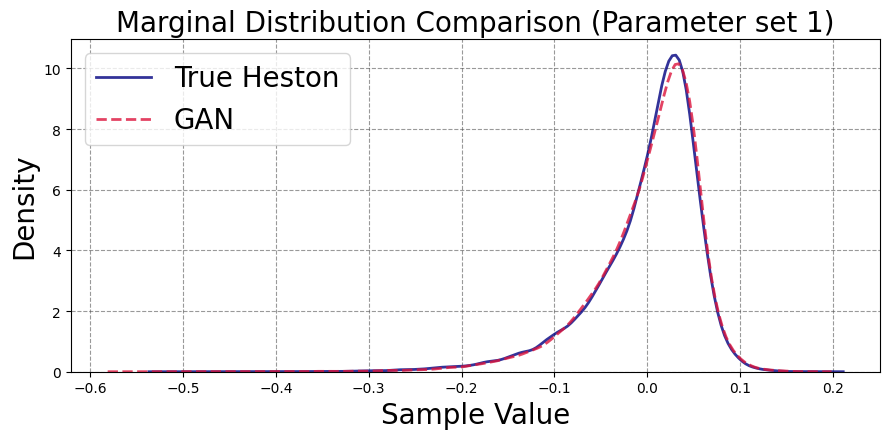


📌 Parameter set 1
    κ = 1.150   γ = 0.590   v̄ = 0.040   ρ = -0.490   ν0 = 0.020   T = 0.247
    📏 Wasserstein distance: 0.0027


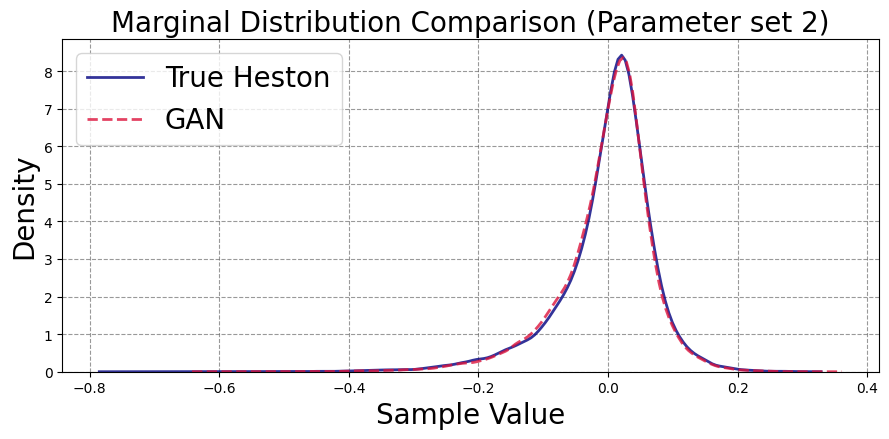


📌 Parameter set 2
    κ = 3.500   γ = 0.700   v̄ = 0.110   ρ = -0.850   ν0 = 0.040   T = 0.329
    📏 Wasserstein distance: 0.0022


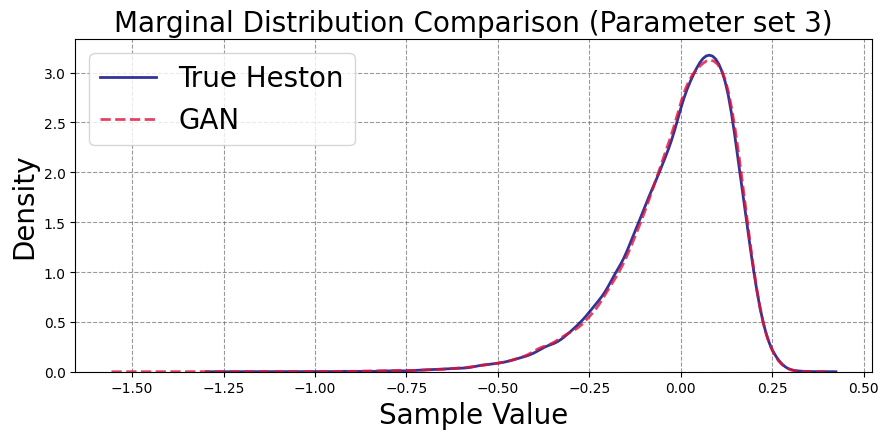


📌 Parameter set 3
    κ = 1.900   γ = 0.450   v̄ = 0.070   ρ = -0.600   ν0 = 0.050   T = 0.493
    📏 Wasserstein distance: 0.0015


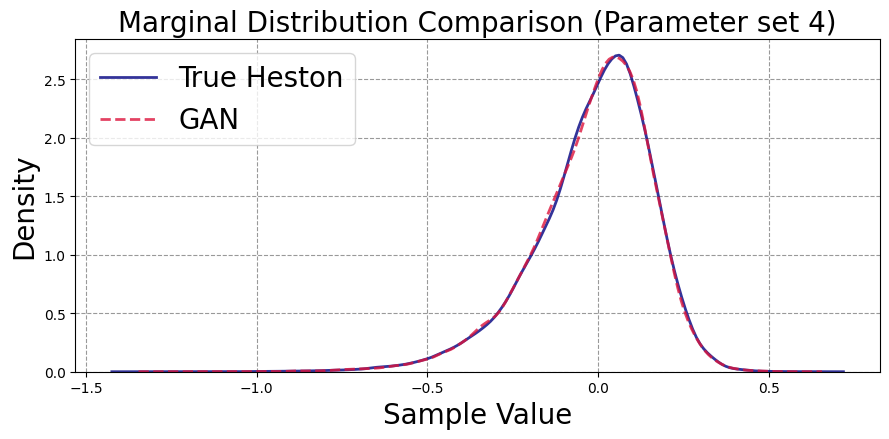


📌 Parameter set 4
    κ = 0.800   γ = 0.690   v̄ = 0.120   ρ = -0.900   ν0 = 0.080   T = 0.685
    📏 Wasserstein distance: 0.0111


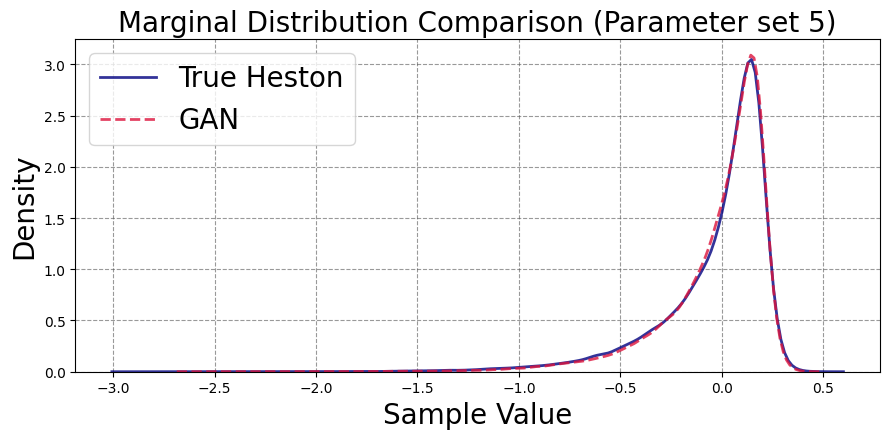


📌 Parameter set 5
    κ = 3.860   γ = 0.400   v̄ = 0.080   ρ = -0.980   ν0 = 0.100   T = 1.000
    📏 Wasserstein distance: 0.0032


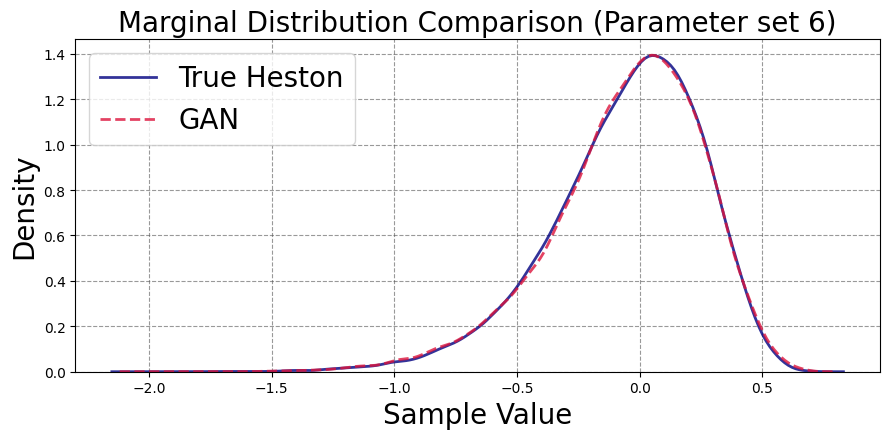

In [10]:
import torch

# Cas typiques calibrés (kappa, gamma, v̄, rho, v0, T)
# Feller ratio = 4 * kappa * v̄ / gamma²
typical_params = torch.tensor([
    [1.5, 0.55, 0.06, -0.75, 0.015, 60/365],   
    [1.15, 0.59, 0.04, -0.49, 0.02, 90/365],  
    [3.5, 0.70, 0.11, -0.85, 0.04, 120/365],   
    [1.9, 0.45, 0.07, -0.6,  0.05, 180/365],  
    [0.8, 0.69, 0.12, -0.9, 0.08, 250/365],  
    [3.86, 0.40, 0.08, -0.98, 0.1, 365/365], 
], dtype=__dtype__, device=__device__)

# Fonction pour calculer le ratio de Feller
def compute_feller_ratio(kappa, gamma, vbar):
    return (2 * kappa * vbar) / (gamma ** 2)

# Affichage des ratios de Feller
for i, row in enumerate(typical_params):
    kappa, gamma, vbar = row[0], row[1], row[2]
    ratio = compute_feller_ratio(kappa, gamma, vbar)
    print(f"Sample {i+1}: Feller ratio ≈ {ratio.item():.2f}")

# Test marginal sur ces cas typiques
show_marginal(
    model,
    dataset=typical_params,
    dtype=__dtype__,
    device=__device__,
)


### Post-processing and distributional evaluation for the Heston model

This section describes the post-processing applied to the generator outputs and the vectorized procedure used to assess distributional accuracy against the Heston benchmark simulator.

---

### Post-processing

The generator outputs raw samples interpreted as terminal log-prices. For the Heston model, no martingale correction is required at this stage and the post-processing consists solely of exponentiation:

$$
S = \exp(X).
$$

The function `HESTON_postprocess` applies this transformation and reshapes the output into a tensor of size $B \times N_{\text{traj}}$, where $B$ is the number of parameter configurations in the batch.

---

### Vectorized distributional evaluation

The function `evaluate_distributional_distance_vectorized` compares the distributions generated by the model with those obtained from a reference Heston simulator over a collection of parameter sets.

For each batch of parameters, the procedure:
- generates $N_{\text{traj}}$ samples from the reference Heston simulator,
- generates $N_{\text{traj}}$ samples from the generator using independent noise,
- applies the same post-processing to both outputs,
- clips values to a fixed cap to ensure numerical stability.

Let $S^{\text{true}}$ and $S^{\text{model}}$ denote the resulting samples.

---

### Moment errors

For each parameter set, the first two moments are compared:
- the mean,
- the standard deviation.

Both absolute and relative errors are reported and then aggregated across the parameter space.

---

### Distributional distances

Two classical distributional distances are used.

The 1-Wasserstein distance is approximated using sorted samples:

$$
W_1
=
\frac{1}{N_{\text{traj}}}
\sum_{j=1}^{N_{\text{traj}}}
\big| S^{\text{true}}_{(j)} - S^{\text{model}}_{(j)} \big|.
$$

The Kolmogorov–Smirnov distance is estimated from histogram-based empirical cumulative distribution functions:

$$
\mathrm{KS}
=
\sup_x
\big| F^{\text{true}}(x) - F^{\text{model}}(x) \big|.
$$

---

### Output

The function returns:
- a dictionary of aggregated metrics including mean values, standard deviations, and worst-case errors,
- the list of batch-wise means for the reference Heston simulator,
- the list of batch-wise means for the generator outputs.

These quantities are used to produce summary tables and figures assessing the in-domain accuracy and robustness of the learned generator.


In [11]:
def HESTON_postprocess(raw_output: torch.Tensor,
                        param_batch: torch.Tensor,
                        N_traj: int) -> torch.Tensor:
    """
    Apply exponentiation to raw GAN outputs from the Heston model.

    Parameters:
    - raw_output: Tensor of shape (B * N_traj,) — the raw output of the generator (log-prices)
    - param_batch: Tensor of shape (B, D) — not used in Heston postprocessing
    - N_traj: number of samples per parameter set

    Returns:
    - Tensor of shape (B, N_traj): the exponentiated outputs
    """
    B = param_batch.shape[0]
    return torch.exp(raw_output).view(B, N_traj)


        
def evaluate_distributional_distance_vectorized(model,
                                                param_tensor: torch.Tensor,
                                                N_traj: int = 10000,
                                                batch_size: int = 512,
                                                noise_size: int = 5,
                                                cap: float = 5.0,
                                                device: str = "cuda",
                                                dtype: torch.dtype = torch.float32,
                                                multi_gpu: bool = True,
                                                reference_process=None,
                                                postprocess=None,
                                                dt: float = 0.001):
    assert reference_process is not None, "A reference process must be provided."
    device = torch.device(device)
    param_tensor = param_tensor.to(dtype=dtype, device=device)
    model = model.to(device).eval()

    if multi_gpu and torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model)

    eps = 1e-6
    N_param = param_tensor.size(0)

    # Containers
    true_means, model_means = [], []
    abs_errors, rel_errors = {k: [] for k in ["mean", "std"]}, {k: [] for k in ["mean", "std"]}
    ks_list, wass_list = [], []

    for i in range(0, N_param, batch_size):
        p_batch = param_tensor[i:i + batch_size]
        B = p_batch.size(0)

        p_expanded = p_batch.unsqueeze(1).expand(B, N_traj, -1).reshape(B * N_traj, -1)

        with torch.no_grad():
            columns = [p_batch[:, j].repeat_interleave(N_traj).to(device) for j in range(p_batch.shape[1])]
            raw_true = reference_process(*columns, dt=dt, dtype=dtype, device=device)

            if postprocess is not None:
                S_true = postprocess(raw_true.view(-1), p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_true = raw_true.view(B, N_traj).clamp(1e-5, cap)

            noise = torch.rand(B * N_traj, noise_size, dtype=dtype, device=device)
            input_tensor = torch.cat([noise, p_expanded], dim=1)
            raw_output = model(input_tensor).view(B * N_traj)

            if postprocess is not None:
                S_model = postprocess(raw_output, p_batch, N_traj).clamp(1e-5, cap)
            else:
                S_model = raw_output.view(B, N_traj).clamp(1e-5, cap)

        # Moments
        true_mean = S_true.mean(dim=1)
        model_mean = S_model.mean(dim=1)
        true_std = S_true.std(dim=1)
        model_std = S_model.std(dim=1)

        # Store mean values
        true_means.append(true_mean.cpu())
        model_means.append(model_mean.cpu())

        # Absolute errors
        abs_errors["mean"].append(torch.abs(model_mean - true_mean).cpu())
        abs_errors["std"].append(torch.abs(model_std - true_std).cpu())

        # Relative errors
        rel_errors["mean"].append((torch.abs(model_mean - true_mean) / (torch.abs(true_mean) + eps)).cpu())
        rel_errors["std"].append((torch.abs(model_std - true_std) / (torch.abs(true_std) + eps)).cpu())

        # Wasserstein-1
        sorted_true, _ = torch.sort(S_true, dim=1)
        sorted_model, _ = torch.sort(S_model, dim=1)
        wass1 = torch.mean(torch.abs(sorted_true - sorted_model), dim=1)
        wass_list.append(wass1.cpu())

        # KS distance
        hist_true = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_true])
        hist_model = torch.stack([torch.histc(x, bins=1000, min=0, max=cap) for x in S_model])
        ecdf_true = torch.cumsum(hist_true, dim=1) / N_traj
        ecdf_model = torch.cumsum(hist_model, dim=1) / N_traj
        ks, _ = torch.max(torch.abs(ecdf_true - ecdf_model), dim=1)
        ks_list.append(ks.cpu())

    # Stack all collected mean values
    true_means_all = torch.cat(true_means)
    model_means_all = torch.cat(model_means)

    final = {
        "true_mean": true_means_all.mean().item(),
        "true_mean_std": true_means_all.std().item(),
        "true_mean_worst": true_means_all[torch.argmax(torch.abs(true_means_all - true_means_all.mean()))].item(),

        "model_mean": model_means_all.mean().item(),
        "model_mean_std": model_means_all.std().item(),
        "model_mean_worst": model_means_all[torch.argmax(torch.abs(model_means_all - model_means_all.mean()))].item(),
    }

    # Absolute and relative errors
    for err_type, container in zip(["abs", "rel"], [abs_errors, rel_errors]):
        for key in container:
            values = torch.cat(container[key])
            final[f"{err_type}_error_{key}_mean"] = values.mean().item()
            final[f"{err_type}_error_{key}_std"] = values.std().item()
            final[f"{err_type}_error_{key}_worst"] = values.max().item()

    # KS and Wasserstein distances
    ks_all = torch.cat(ks_list)
    wass_all = torch.cat(wass_list)
    final["ks_distance_mean"] = ks_all.mean().item()
    final["ks_distance_std"] = ks_all.std().item()
    final["ks_distance_worst"] = ks_all.max().item()

    final["wasserstein_1_mean"] = wass_all.mean().item()
    final["wasserstein_1_std"] = wass_all.std().item()
    final["wasserstein_1_worst"] = wass_all.max().item()

    return final, true_means, model_means  # 👈 retourne aussi les listes




### Distributional evaluation over random Heston parameters

This experiment evaluates the distributional accuracy of the trained generator over randomly sampled Heston parameter configurations.

Parameter vectors are generated within the prescribed training ranges for $\kappa$, $\gamma$, $\bar v$, $\rho$, $v_0$, and $T$, with an additional constraint on the Feller ratio. For each configuration, the model distribution is compared to the Heston benchmark simulator using moment errors and distributional distances. All metrics are aggregated into a summary table reporting mean, standard deviation, and worst-case statistics across the parameter space.

---

### ⚠️ Important note on experimental scale

The results reported in the associated paper are obtained using large-scale experiments with:
- $n_{\text{simu}} = 100\,000$ parameter configurations,
- $N_{\text{traj}} = 100\,000$ samples per configuration.

In this notebook, we deliberately use reduced values $n_{\text{simu}} = 100$ and $N_{\text{traj}} = 10\,000$ to ensure that the code can run on standard hardware within a reasonable execution time.

These reduced settings are intended for demonstration and reproducibility only and should not be interpreted as the final quantitative results reported in the paper.

---

### Output

The summary table is exported to CSV and LaTeX formats for direct inclusion in reports and manuscripts.


In [12]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

_params_ = {
    "nb_simu": 100,
    "log_model": True,
    "KAPPAS" :[0.5, 4.0], 
    "GAMMAS" : [0.1, 0.8],
    "VBARS" : [0.01, 0.15],
    "RHOS" : [-0.99, -0.3],
    "v0" : [0.01, 0.12],
    "T" : [60/365, 365/365],
    "dt": 0.001,
    "cap": 3.0,
    "dtype": __dtype__,
    "device": __device__,
    "feller_ratio" : [0.4, 10.0]
}

# Test marginal with T fixed at 0.25
D = HESTON_param(random_param = True, **_params_).params

# Evaluate the model
results, true_means, model_means = evaluate_distributional_distance_vectorized(
    model, D, N_traj=10_000, batch_size=2, device="cuda",
    multi_gpu=True, reference_process=HESTON, postprocess=HESTON_postprocess
)

# Format results into table
table = []

# 1. Add true_mean and model_mean first
for base in ["true_mean", "model_mean"]:
    table.append({
        "Metric": base,
        "Mean": results[base],
        "Worst case": results.get(f"{base}_worst", None),
        "Std": results.get(f"{base}_std", None)
    })

# Skip these since they were already handled
skip_keys = [
    "true_mean", "model_mean",
    "true_mean_std", "model_mean_std",
    "true_mean_worst", "model_mean_worst"
]

# 2. Process the rest of the metrics
for metric, value in results.items():
    if metric in skip_keys:
        continue

    if metric.endswith("_mean"):
        base = metric[:-5]
        std_key = base + "_std"
        worst_key = base + "_worst"
        std_val = results.get(std_key, None)
        worst_val = results.get(worst_key, None)

        # Convert relative errors to percent
        if base.startswith("rel_error_"):
            value *= 100
            if std_val is not None:
                std_val *= 100
            if worst_val is not None:
                worst_val *= 100

        table.append({
            "Metric": base,
            "Mean": value,
            "Worst case": worst_val,
            "Std": std_val
        })

    elif any(metric.endswith(suffix) for suffix in ["_std", "_worst"]):
        continue

    else:
        table.append({
            "Metric": metric,
            "Mean": value,
            "Worst case": None,
            "Std": None
        })

# Build DataFrame
df = pd.DataFrame(table)
df = df[["Metric", "Mean", "Worst case", "Std"]]
df.set_index("Metric", inplace=True)
df = df.round(6)


# Display
print("📊 Heston Model – Distributional Distance Summary (% for relative errors):")
display(
    df.style.set_caption("Variance gamma model – Moment Errors and Distances")
      .format(precision=3)
      .background_gradient(subset=["Mean"], cmap="Blues", low=0.2, high=0.6)
)



/usr/local/lib/python3.11/dist-packages/torch/nn/modules/linear.py:116: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)


📊 Heston Model – Distributional Distance Summary (% for relative errors):


,Mean,Worst case,Std
Metric,,,
true_mean,0.999,0.989,0.004
model_mean,0.999,1.011,0.004
abs_error_mean,0.002,0.009,0.002
abs_error_std,0.002,0.008,0.001
rel_error_mean,0.239,0.882,0.196
rel_error_std,1.070,3.506,0.786
ks_distance,0.014,0.032,0.005
wasserstein_1,0.004,0.009,0.002
